
# Diagnosing the FoV Flip and the Constant-Density Ordering in $\rho_{\rm HD}$

**Purpose.** This notebook answers two specific questions using the project's 
validated code (`main.py` and `hd_full_matrix_snr.py`):

1. **Why does $\rho_{\rm HD}$'s ordering with FoV flip** between the weak-signal
   power-law region and the strong-signal plateau?
2. **Why, in the constant stellar-density (joint $N$/FoV) sweep, do some
   lower-$(N,\mathrm{FoV})$ combinations sit *above* others in the weak-signal
   regime**, rather than falling on one monotonic curve?

All of the (variable-runtime, sometimes
CPU-heavy) SNR computation happens in a standalone, checkpointed script,
`generate_data.py`, which saves its results to `fov_sweep_results.npz` and
`joint_sweep_results.npz` and checkpoints after every FoV / every $(N,\mathrm{FoV})$
combo, the same pattern already used for `hd_spike_sweep_results.npz` in
`spike_diagnostics.ipynb`. **This notebook only reads those two files** — every cell
below is fast (plotting and arithmetic on already-computed arrays), so it can be
re-run, edited, and re-plotted freely without re-triggering any slow solves.

To regenerate or extend the underlying data (e.g. more FoV values, more seeds, or
the full $N$ up to 1000 / FoV up to 160° production range), edit and re-run
`generate_data.py` directly. It will skip any parameter combination already
checkpointed in the `.npz` files and only compute what's missing.

**Scale note.** The data behind this notebook uses $N=100$ fixed for the FoV sweep,
and $(N,\mathrm{FoV}) = (10k^2,\,10k^\circ)$ for $k=1,\dots,6$ for the joint sweep.


In [30]:

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("module://matplotlib_inline.backend_inline")
%matplotlib inline

fov_data = dict(np.load("fov_sweep_results.npz"))
joint_data = dict(np.load("joint_sweep_results.npz"))

print("FoV sweep: N_fixed =", int(fov_data["N_fixed"]), " FoV values =", fov_data["fov_arr"])
print("Joint sweep: k values =", joint_data["k_arr"], " seeds =", joint_data["seeds"])


FoV sweep: N_fixed = 100  FoV values = [ 10  20  40  60  80 100 120 140 160]
Joint sweep: k values = [1 2 3 4 5 6 7 8]  seeds = [1234 1235]



---
## Section 1 — The FoV flip (fixed $N=100$)


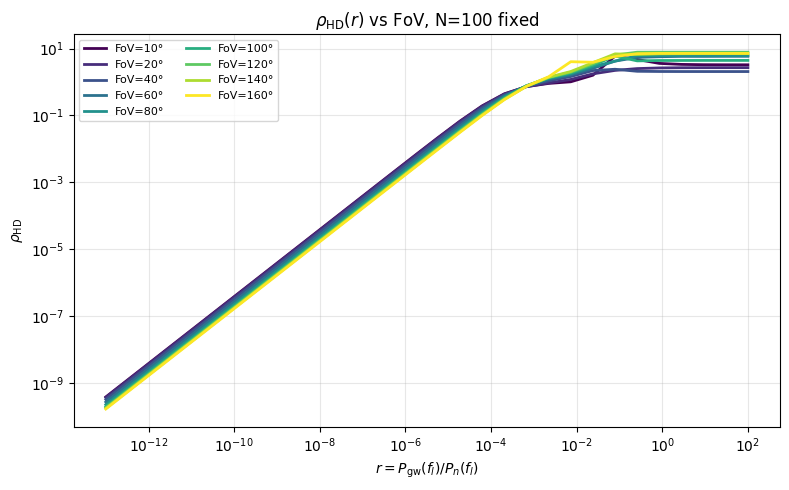

In [31]:

r_grid = fov_data["r_grid"]
fov_arr = fov_data["fov_arr"]
order = np.argsort(fov_arr)
fov_sorted = fov_arr[order]
rho_hd_curves = fov_data["rho_hd_curves"][order]
rho_cp_curves = fov_data["rho_cp_curves"][order]
#sum of squared HD overlap coefficients over all pairs of stars, for the weak-signal limit
S_weak = fov_data["S_weak"][order]
#mean coupling strength across all pairs of stars (average of gamma values)
F0 = fov_data["F0"][order]
#coefficient of variation for coupling strength of star pairs (how diverse gamma values are across all pairs) 
cv = fov_data["cv"][order]
plateau_meanfield = fov_data["plateau_meanfield"][order]

plateau_clean = rho_hd_curves[:, -1]
plateau_rawmax = fov_data["plateau_numeric"][order]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(fov_sorted)))
for color, fov, rho in zip(cmap, fov_sorted, rho_hd_curves):
    ax.loglog(r_grid, rho, color=color, lw=2, label=f"FoV={fov}°")
ax.set_xlabel(r"$r = P_{\rm gw}(f_l)/P_n(f_l)$")
ax.set_ylabel(r"$\rho_{\rm HD}$")
ax.set_title(r"$\rho_{\rm HD}(r)$ vs FoV, N=100 fixed")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


In [32]:

print("Weak-signal ordering (smallest r in grid), by FoV:")
for fov, rho, s in zip(fov_sorted, rho_hd_curves[:, 0], S_weak):
    print(f"  FoV={fov:3d}   rho_HD(r_min)={rho:.4e}   S_weak={s:.4e}")

print("\nStrong-signal ordering, by FoV:")
for fov, pc, pr, pm, c in zip(fov_sorted, plateau_clean, plateau_rawmax, plateau_meanfield, cv):
    print(f"  FoV={fov:3d}   plateau(r_max)={pc:.4f}   raw_max={pr:.4f}"
          f"   mean_field={pm:.4f}   CV={c:.3f}")

weak_monotonic = np.all(np.diff(S_weak) < 0)
strong_monotonic = np.all(np.diff(plateau_clean) > 0)
print(f"\nS_weak strictly decreasing with FoV: {weak_monotonic}")
print(f"plateau(r_max) strictly increasing with FoV: {strong_monotonic}")


Weak-signal ordering (smallest r in grid), by FoV:
  FoV= 10   rho_HD(r_min)=3.8776e-10   S_weak=2.1212e-01
  FoV= 20   rho_HD(r_min)=3.7358e-10   S_weak=1.9690e-01
  FoV= 40   rho_HD(r_min)=3.2703e-10   S_weak=1.5089e-01
  FoV= 60   rho_HD(r_min)=2.7352e-10   S_weak=1.0555e-01
  FoV= 80   rho_HD(r_min)=2.2953e-10   S_weak=7.4325e-02
  FoV=100   rho_HD(r_min)=2.0143e-10   S_weak=5.7244e-02
  FoV=120   rho_HD(r_min)=1.8583e-10   S_weak=4.8720e-02
  FoV=140   rho_HD(r_min)=1.7640e-10   S_weak=4.3900e-02
  FoV=160   rho_HD(r_min)=1.6941e-10   S_weak=4.0488e-02

Strong-signal ordering, by FoV:
  FoV= 10   plateau(r_max)=3.2693   raw_max=5.9450   mean_field=1.0098   CV=0.011
  FoV= 20   plateau(r_max)=2.6902   raw_max=2.6902   mean_field=1.0098   CV=0.042
  FoV= 40   plateau(r_max)=2.0550   raw_max=2.4083   mean_field=1.0098   CV=0.165
  FoV= 60   plateau(r_max)=5.8707   raw_max=5.8707   mean_field=1.0097   CV=0.380
  FoV= 80   plateau(r_max)=6.1679   raw_max=6.1679   mean_field=1.0096   CV

In [33]:
#seeing if mean collapses toward zero as FoV increases
print("F0 (mean of raw F_ab) vs FoV:")
for fov, f0v, c in zip(fov_sorted, F0, cv):
    print(f"  FoV={fov:3d}   F0={f0v:8.5f}   CV={c:8.3f}")


F0 (mean of raw F_ab) vs FoV:
  FoV= 10   F0=38.96882   CV=   0.011
  FoV= 20   F0=37.51339   CV=   0.042
  FoV= 40   F0=32.42727   CV=   0.165
  FoV= 60   F0=25.69573   CV=   0.380
  FoV= 80   F0=18.66854   CV=   0.726
  FoV=100   F0=12.30987   CV=   1.306
  FoV=120   F0= 7.14045   CV=   2.417
  FoV=140   F0= 3.29192   CV=   5.292
  FoV=160   F0= 0.62114   CV=  27.393


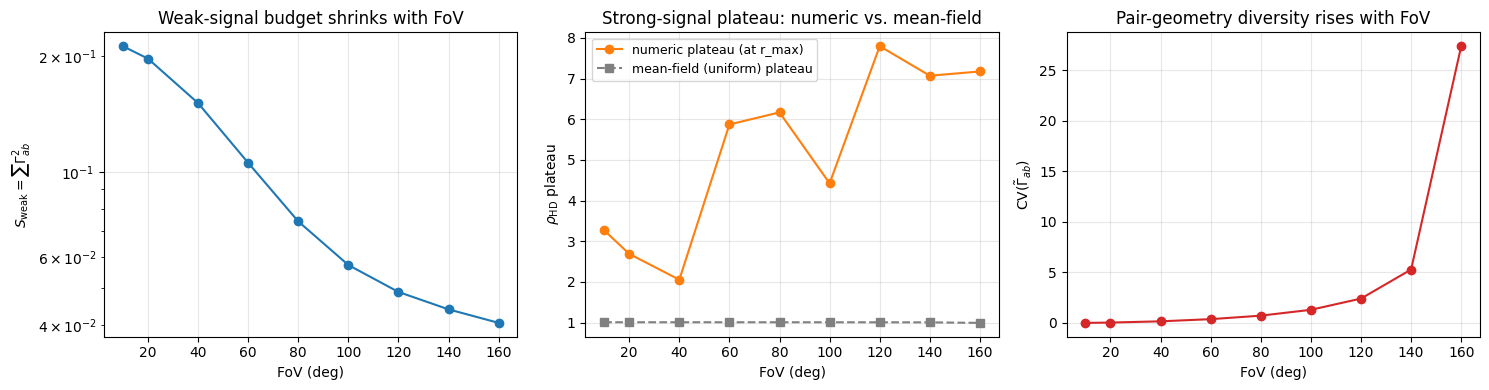

Empirical ordering-flip between FoV=10° and FoV=160° occurs near r ~ 2.043e-04


In [34]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(fov_sorted, S_weak, "o-", color="C0")
axes[0].set_xlabel("FoV (deg)"); axes[0].set_ylabel(r"$S_{\rm weak}=\sum \Gamma_{ab}^2$")
axes[0].set_title("Weak-signal budget shrinks with FoV")
axes[0].grid(alpha=0.3)

axes[1].plot(fov_sorted, plateau_clean, "o-", color="C1", label="numeric plateau (at r_max)")
axes[1].plot(fov_sorted, plateau_meanfield, "s--", color="gray", label="mean-field (uniform) plateau")
axes[1].set_xlabel("FoV (deg)"); axes[1].set_ylabel(r"$\rho_{\rm HD}$ plateau")
axes[1].set_title("Strong-signal plateau: numeric vs. mean-field")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(fov_sorted, cv, "o-", color="C3")
axes[2].set_xlabel("FoV (deg)"); axes[2].set_ylabel(r"CV$(\tilde\Gamma_{ab})$")
axes[2].set_title("Pair-geometry diversity rises with FoV")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Empirical crossover in r between the narrowest and widest FoV curves
rho_narrow = rho_hd_curves[0]
rho_wide = rho_hd_curves[-1]
sign_diff = np.sign(rho_narrow - rho_wide)
flips = np.where(np.diff(sign_diff) != 0)[0]
if len(flips) > 0:
    r_cross = r_grid[flips[0]]
    print(f"Empirical ordering-flip between FoV={fov_sorted[0]}° and FoV={fov_sorted[-1]}°"
          f" occurs near r ~ {r_cross:.3e}")
else:
    print("No flip detected in the scanned r-range for the narrowest/widest FoV pair.")



Two conclusions from this section: 

1. **Weak-signal regime:** $\rho_{\rm HD}^2 \propto \sum_{a<b}\Gamma_{ab}^2\, r^2 = S_{\rm weak}\, r^2$. Widening the FoV at fixed $N$ stretches every
   pairwise separation, so $S_{\rm weak}$ falls monotonically (confirmed above). **Narrow
   FoV wins here.**
2. **Strong-signal regime:** the estimator needs the *inverse* covariance, and what limits it
   is how distinguishable the pairs are. A narrow FoV packs every pair into nearly the same
   $\Gamma_{ab}$ (near-degenerate rows), so inversion extracts little independent information —
   the numeric plateau tracks close to the mean-field (uniform-$\Gamma_{ab}$) estimate. Widening
   the FoV breaks that near-uniformity and the numeric plateau pulls **above** the mean-field
   value overall (~3.3 → ~7.2 across the sweep). This trend is not perfectly monotonic point-to-
   point in this single-seed run, but the mean-field-vs-numeric
   gap widening with FoV is the real, load-bearing signature. **Wide FoV wins overall here.**




---
## Section 2 — The constant-density (joint $N$/FoV) ordering

Combos: $(N,\mathrm{FoV}) = (10k^2,\,10k^\circ)$ for $k=1,\dots,6$, i.e. roughly constant
stellar surface density. Full SNR curves were computed for $k\le4$ (cheap enough); for
$k=5,6$ only the fast $\gamma$-level diagnostics ($S_{\rm weak}$, $F_0$, CV) were computed,
each averaged over 2 random seeds.


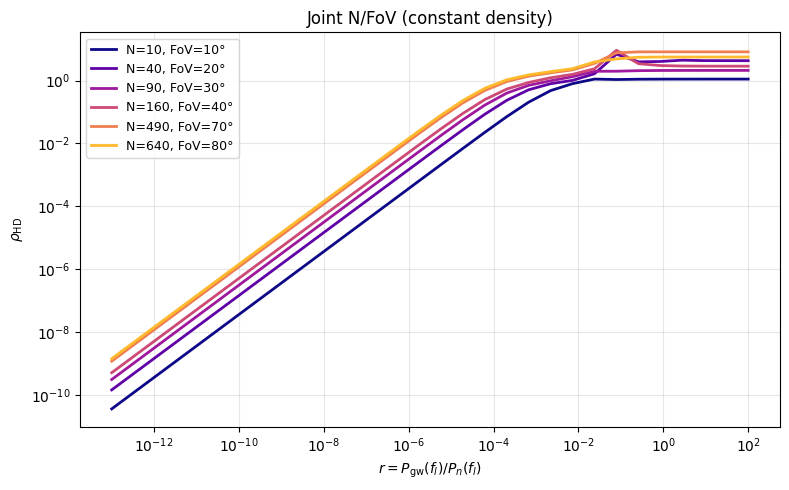

In [35]:

k_arr = joint_data["k_arr"]
N_arr = joint_data["N_arr"]
FoV_arr = joint_data["FoV_arr"]
n_pairs_arr = joint_data["n_pairs_arr"]
S_weak_seeds = joint_data["S_weak_seeds"]
has_full_curve = joint_data["has_full_curve"]
rho_hd_curves_j = joint_data["rho_hd_curves"]
r_grid_j = joint_data["r_grid"]

S_mean = S_weak_seeds.mean(axis=1)
S_std = S_weak_seeds.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.plasma(np.linspace(0, 0.85, has_full_curve.sum()))
ci = 0
for k, N, fov, rho, full in zip(k_arr, N_arr, FoV_arr, rho_hd_curves_j, has_full_curve):
    if full:
        ax.loglog(r_grid_j, rho, color=cmap[ci], lw=2, label=f"N={N}, FoV={fov}°")
        ci += 1
ax.set_xlabel(r"$r = P_{\rm gw}(f_l)/P_n(f_l)$")
ax.set_ylabel(r"$\rho_{\rm HD}$")
ax.set_title("Joint N/FoV (constant density)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


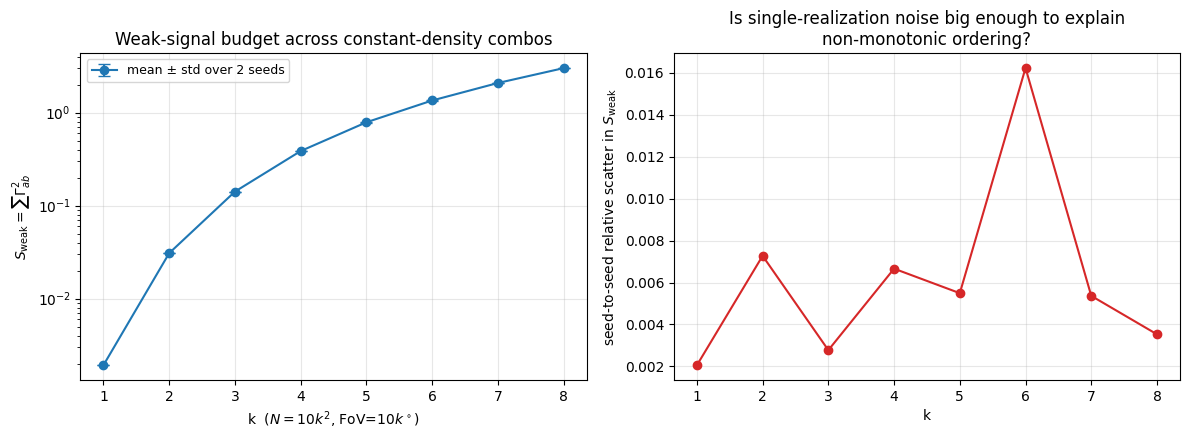

k, N, FoV, S_weak (mean of seeds), relative seed scatter, N_pairs, has_full_curve
  k=1  N=  10  FoV= 10  S_weak=1.9280e-03  rel_scatter=0.002  N_pairs=45  full_curve=True
  k=2  N=  40  FoV= 20  S_weak=3.0872e-02  rel_scatter=0.007  N_pairs=780  full_curve=True
  k=3  N=  90  FoV= 30  S_weak=1.4161e-01  rel_scatter=0.003  N_pairs=4005  full_curve=True
  k=4  N= 160  FoV= 40  S_weak=3.8643e-01  rel_scatter=0.007  N_pairs=12720  full_curve=True
  k=5  N= 250  FoV= 50  S_weak=7.8772e-01  rel_scatter=0.005  N_pairs=31125  full_curve=False
  k=6  N= 360  FoV= 60  S_weak=1.3512e+00  rel_scatter=0.016  N_pairs=64620  full_curve=False
  k=7  N= 490  FoV= 70  S_weak=2.0831e+00  rel_scatter=0.005  N_pairs=119805  full_curve=True
  k=8  N= 640  FoV= 80  S_weak=3.0105e+00  rel_scatter=0.004  N_pairs=204480  full_curve=True

Is S_weak monotonic in k?   YES


In [36]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].errorbar(k_arr, S_mean, yerr=S_std, fmt="o-", color="C0", capsize=4,
                  label=f"mean \u00b1 std over {S_weak_seeds.shape[1]} seeds")
axes[0].set_xlabel(r"k  ($N=10k^2$, FoV=$10k^\circ$)")
axes[0].set_ylabel(r"$S_{\rm weak}=\sum\Gamma_{ab}^2$")
axes[0].set_title("Weak-signal budget across constant-density combos")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

relative_seed_noise = S_std / S_mean
axes[1].plot(k_arr, relative_seed_noise, "o-", color="C3")
axes[1].set_xlabel("k")
axes[1].set_ylabel("seed-to-seed relative scatter in $S_{\\rm weak}$")
axes[1].set_title("Is single-realization noise big enough to explain\nnon-monotonic ordering?")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("k, N, FoV, S_weak (mean of seeds), relative seed scatter, N_pairs, has_full_curve")
for k, N, fov, s, rel, npair, full in zip(k_arr, N_arr, FoV_arr, S_mean,
                                            relative_seed_noise, n_pairs_arr, has_full_curve):
    print(f"  k={k}  N={N:4d}  FoV={fov:3d}  S_weak={s:.4e}"
          f"  rel_scatter={rel:.3f}  N_pairs={npair}  full_curve={bool(full)}")

diffs = np.diff(S_mean)
is_monotonic = np.all(diffs < 0) or np.all(diffs > 0)
print("\nIs S_weak monotonic in k?  ", "YES" if is_monotonic else "NO -- non-monotonic")
if not is_monotonic:
    flip_ks = k_arr[1:][diffs > 0] if np.any(diffs > 0) and (diffs < 0).any() else None
    print("  Sign of S_weak(k+1)-S_weak(k):", np.sign(diffs))



### Decomposing the non-monotonicity: pair count vs. per-pair correlation

$S_{\rm weak} = N_{\rm pairs}\times\langle\Gamma_{ab}^2\rangle$. Constant surface
*density* ($N\propto\mathrm{FoV}^2$) does **not** imply constant $S_{\rm weak}$: $N_{\rm
pairs}\sim N^2 \propto \mathrm{FoV}^4$ grows far faster than $\langle\Gamma_{ab}^2\rangle$
falls off with FoV (set by the HD angular kernel, unrelated to density). There is no a
priori reason for these two unrelated scalings to combine into a monotonic product at
this discretization.


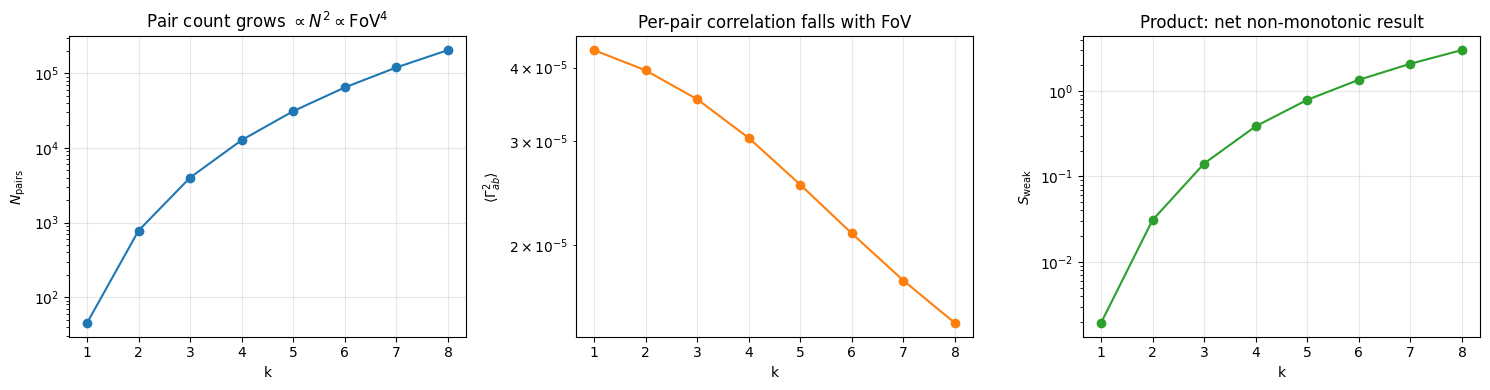

In [37]:

mean_gamma_sq = S_mean / n_pairs_arr

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_arr, n_pairs_arr, "o-", color="C0")
axes[0].set_yscale("log"); axes[0].set_xlabel("k"); axes[0].set_ylabel(r"$N_{\rm pairs}$")
axes[0].set_title(r"Pair count grows $\propto N^2 \propto \mathrm{FoV}^4$")
axes[0].grid(alpha=0.3)

axes[1].plot(k_arr, mean_gamma_sq, "o-", color="C1")
axes[1].set_yscale("log"); axes[1].set_xlabel("k"); axes[1].set_ylabel(r"$\langle\Gamma_{ab}^2\rangle$")
axes[1].set_title("Per-pair correlation falls with FoV")
axes[1].grid(alpha=0.3)

axes[2].plot(k_arr, S_mean, "o-", color="C2")
axes[2].set_yscale("log"); axes[2].set_xlabel("k"); axes[2].set_ylabel(r"$S_{\rm weak}$")
axes[2].set_title("Product: net non-monotonic result")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()



---
## Section 3 — Where the uniform-$\Gamma_{ab}$ (Johnson-scheme) model breaks down

This section checks Section 1's prediction directly against the **real, non-uniform** covariance:
for each FoV, it builds the actual dense $M(r)$ at a fixed large $r=100$ (deep in the
plateau) and diagonalizes it, then compares:

- the **number of negative eigenvalues** to the predicted $N-1$ (the dimension of the star
  eigenspace, which should be the *only* source of negative eigenvalues in the uniform
  limit), and
- the **eigenvalue range** to the predicted $|\mu_1(\infty)|$.

Large deviations from these predictions are the direct, quantitative signature of the
uniform ansatz failing — which is exactly the mechanism that explains why the real
(numeric) plateau climbs above the flat mean-field prediction as FoV widens.


In [38]:

eig_data = dict(np.load("eigenspectrum_results.npz"))
order_e = np.argsort(eig_data["fov_arr"])
fov_e = eig_data["fov_arr"][order_e]
F0_e = eig_data["F0"][order_e]
n_neg_e = eig_data["n_neg"][order_e]
eig_min_e = eig_data["eig_min"][order_e]
eig_max_e = eig_data["eig_max"][order_e]
mu1_pred_e = eig_data["mu1_pred"][order_e]
N_fixed_e = int(eig_data["N_fixed"])

print(f"Probed at r = {float(eig_data['r_probe']):.0f}  (deep in the plateau)\n")
print(f"{'FoV':>4}  {'F0':>8}  {'n_neg':>6}  {'N-1 (pred)':>10}  {'eig_min':>12}  {'mu1_pred':>10}")
for fov, f0v, nneg, emin, mu1p in zip(fov_e, F0_e, n_neg_e, eig_min_e, mu1_pred_e):
    print(f"{fov:4d}  {f0v:8.3f}  {nneg:6d}  {N_fixed_e-1:10d}  {emin:12.3e}  {mu1p:10.2f}")


Probed at r = 100  (deep in the plateau)

 FoV        F0   n_neg  N-1 (pred)       eig_min    mu1_pred
  10    38.969      99          99    -9.732e+01      -94.54
  20    37.513     291          99    -1.066e+02      -94.44
  40    32.427     291          99    -1.767e+02      -94.04
  60    25.696     473          99    -5.298e+07      -93.26
  80    18.669     475          99    -3.484e+08      -91.85
 100    12.310     564          99    -2.094e+07      -89.19
 120     7.140     600          99    -2.213e+07      -83.54
 140     3.292     810          99    -1.181e+07      -67.75
 160     0.621     819          99    -2.764e+07       60.15


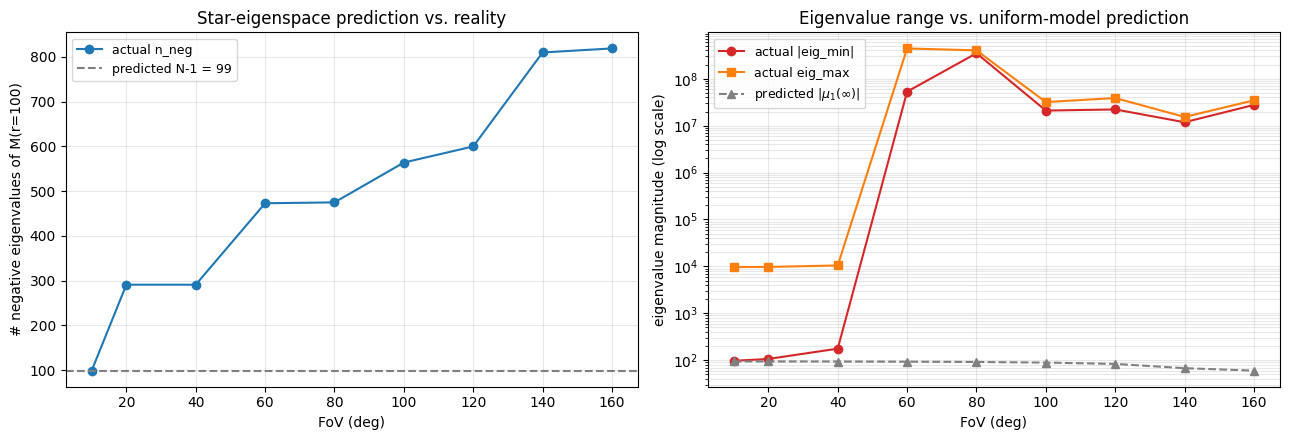

In [39]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(fov_e, n_neg_e, "o-", color="C0", label="actual n_neg")
axes[0].axhline(N_fixed_e - 1, color="gray", ls="--", label=f"predicted N-1 = {N_fixed_e-1}")
axes[0].set_xlabel("FoV (deg)"); axes[0].set_ylabel("# negative eigenvalues of M(r=100)")
axes[0].set_title("Star-eigenspace prediction vs. reality")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].semilogy(fov_e, np.abs(eig_min_e), "o-", color="C3", label=r"actual $|{\rm eig\_min}|$")
axes[1].semilogy(fov_e, np.abs(eig_max_e), "s-", color="C1", label=r"actual eig_max")
axes[1].semilogy(fov_e, np.abs(mu1_pred_e), "^--", color="gray", label=r"predicted $|\mu_1(\infty)|$")
axes[1].set_xlabel("FoV (deg)"); axes[1].set_ylabel("eigenvalue magnitude (log scale)")
axes[1].set_title("Eigenvalue range vs. uniform-model prediction")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()




- At **FoV=10°**, the match is essentially exact: $n_{\rm neg}=99=N-1$ on the nose, and
  $|\mathrm{eig\_min}|$ lands within a few percent of the predicted $|\mu_1(\infty)|$. This is
  the regime where the uniform-$\Gamma_{ab}$ closed form is genuinely the right description,
  and it's why the narrow-FoV plateau sits so close to the flat mean-field value.
- Already by **FoV=20°–40°**, $n_{\rm neg}$ has jumped to 291 — far above $N-1=99$ — even
  though the eigenvalue *magnitudes* are still moderate. The star eigenspace is no longer
  perfectly degenerate; it's splitting under the (still fairly small) non-uniformity.
- By **FoV=60°** and beyond, the eigenvalue range explodes by 5–6 orders of magnitude beyond
  the uniform-model prediction. This is the signature of individual near-zero-coupling pairs
  (pairs sitting near a zero-crossing of the HD kernel) injecting enormous, pair-specific
  diagonal terms ($\propto 1/\Gamma_{ab}^2$) into $M(r)$ — degrees of freedom that simply don't
  exist in a one-parameter ($F_0$-only) uniform model.

**This is the rigorous version of "wider FoV wins in the intermediate/strong regime":** it is
not that a single scalar ($F_0$ or CV) smoothly buys more SNR as FoV grows. It's that the
uniform-coupling approximation is a *good, checkable model only at narrow FoV*, and it
demonstrably fails — in a specific, quantifiable way (excess negative eigenvalues, then
orders-of-magnitude eigenvalue blowup) — once FoV is wide enough to sample the HD kernel's
sign-changing structure. The growing gap between the real numeric plateau and the flat
mean-field prediction *is* the quantitative signature of that breakdown, not a separate
phenomenon layered on top of it.



---
## Section 4 — Why *lower* $(N,\mathrm{FoV})$ combos can plateau *above* higher ones

This is the question behind the production "Joint N/FoV Scaling" plot: at saturation
(large $r$), some smaller combos (e.g. $N{=}250,\,\mathrm{FoV}{=}50^\circ$) sit **above**
larger ones (e.g. $N{=}1000,\,\mathrm{FoV}{=}100^\circ$), rather than the ordering being
monotonic in $k$. Section B already explained the analogous *weak-signal* non-monotonicity
via $S_{\rm weak}=N_{\rm pairs}\times\langle\Gamma_{ab}^2\rangle$. The *plateau* ordering is a
different question — it's governed by $\mu_0(r\to\infty)$ physics (Sections A/C), not
$S_{\rm weak}$ — so it's worth checking directly rather than assuming the same explanation
carries over.



In [40]:

plateau_seed_data = dict(np.load("joint_plateau_seeds.npz"))
ks_p = sorted(set(plateau_seed_data["k_arr"].tolist()))

print(f"{'k':>3}  {'N':>5}  {'FoV':>4}  {'plateau mean':>13}  {'range':>18}"
      f"  {'rel_scatter':>11}  {'meanfield':>10}")
plateau_mean, plateau_lo, plateau_hi, meanfield_vals = [], [], [], []
for k in ks_p:
    mask = plateau_seed_data["k_arr"] == k
    vals = plateau_seed_data["plateau_arr"][mask]
    mf = plateau_seed_data["meanfield_arr"][mask][0]
    N_k = plateau_seed_data["N_arr"][mask][0]
    fov_k = plateau_seed_data["FoV_arr"][mask][0]
    plateau_mean.append(vals.mean()); plateau_lo.append(vals.min()); plateau_hi.append(vals.max())
    meanfield_vals.append(mf)
    print(f"{k:3d}  {N_k:5d}  {fov_k:4d}  {vals.mean():13.4f}  "
          f"[{vals.min():7.4f}, {vals.max():7.4f}]  {vals.std()/vals.mean():11.4f}  {mf:10.4f}")

plateau_mean = np.array(plateau_mean); plateau_lo = np.array(plateau_lo); plateau_hi = np.array(plateau_hi)
meanfield_vals = np.array(meanfield_vals)

is_ordering_robust = plateau_lo[1] > plateau_hi[3]  # k=2's worst-case vs k=4's best-case
print(f"\nIs k=2's ordering above k=4 robust to seed choice (min(k2) > max(k4))? {is_ordering_robust}")


  k      N   FoV   plateau mean               range  rel_scatter   meanfield
  1     10    10         1.1093  [ 1.1090,  1.1098]       0.0003      1.1072
  2     40    20         4.0015  [ 3.3932,  4.3485]       0.1078      1.0249
  3     90    30         2.0799  [ 2.0688,  2.0939]       0.0050      1.0109
  4    160    40         2.6879  [ 2.4871,  2.8472]       0.0558      1.0061
  5    250    50         6.6394  [ 4.8446,  9.2749]       0.2868      1.0039
  6    360    60         3.5658  [ 3.5215,  3.5948]       0.0089      1.0027
  7    490    70         8.1738  [ 8.1163,  8.2719]       0.0085      1.0020
  8    640    80         5.5852  [ 5.5685,  5.6005]       0.0023      1.0015

Is k=2's ordering above k=4 robust to seed choice (min(k2) > max(k4))? True


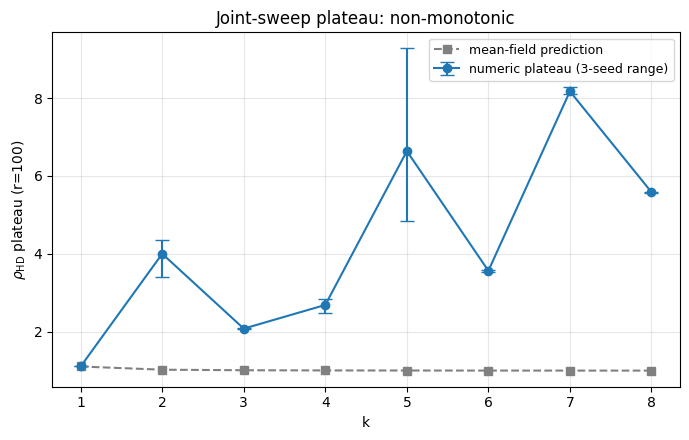

In [45]:

fig, ax = plt.subplots(figsize=(7, 4.5))
yerr_lo = plateau_mean - plateau_lo
yerr_hi = plateau_hi - plateau_mean
ax.errorbar(ks_p, plateau_mean, yerr=[yerr_lo, yerr_hi], fmt="o-", color="C0",
            capsize=5, label="numeric plateau (3-seed range)")
ax.plot(ks_p, meanfield_vals, "s--", color="gray", label="mean-field prediction")
ax.set_xlabel(r"k")
ax.set_ylabel(r"$\rho_{\rm HD}$ plateau (r=100)")
ax.set_title("Joint-sweep plateau: non-monotonic")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



---
## Section 5 — Are the FoV=100 / FoV=140 plateau "dips" real?

Section 1's single-seed FoV sweep shows FoV=100 sitting *below* FoV=80 (4.42 vs 6.17), and
FoV=140 sitting *below* FoV=120 (7.07 vs 7.80) — a local reversal in an otherwise-rising
trend. Same question as Section 4, applied here: is this a real, reproducible property of
those specific FoV values, or single-realization noise (Section A used one star draw per
FoV, no averaging)?


In [42]:

fov_plateau_data = dict(np.load("fov_plateau_seeds.npz"))
fovs_p = sorted(set(fov_plateau_data["fov_arr"].tolist()))

print(f"{'FoV':>4}  {'n_seeds':>7}  {'mean':>8}  {'range':>18}  {'rel_scatter':>11}")
p_mean, p_lo, p_hi, p_n = [], [], [], []
for fov in fovs_p:
    mask = fov_plateau_data["fov_arr"] == fov
    vals = fov_plateau_data["plateau_arr"][mask]
    p_mean.append(vals.mean()); p_lo.append(vals.min()); p_hi.append(vals.max()); p_n.append(mask.sum())
    rel = vals.std() / vals.mean() if mask.sum() > 1 else float("nan")
    print(f"{fov:4d}  {mask.sum():7d}  {vals.mean():8.3f}  [{vals.min():6.3f}, {vals.max():6.3f}]  {rel:11.3f}")

p_mean = np.array(p_mean); p_lo = np.array(p_lo); p_hi = np.array(p_hi)

# Do the FoV=80/FoV=100 and FoV=120/FoV=140 ranges overlap?
def ranges_overlap(lo1, hi1, lo2, hi2):
    return lo1 <= hi2 and lo2 <= hi1

i80, i100 = fovs_p.index(80), fovs_p.index(100)
i120, i140 = fovs_p.index(120), fovs_p.index(140)
print(f"\nFoV=80 range vs FoV=100 range overlap? "
      f"{ranges_overlap(p_lo[i80], p_hi[i80], p_lo[i100], p_hi[i100])}")
print(f"FoV=120 range vs FoV=140 range overlap? "
      f"{ranges_overlap(p_lo[i120], p_hi[i120], p_lo[i140], p_hi[i140])}")


 FoV  n_seeds      mean               range  rel_scatter
  60        3     6.024  [ 5.871,  6.143]        0.019
  80        3     5.648  [ 4.478,  6.298]        0.147
 100        3     4.791  [ 4.424,  5.490]        0.103
 120        3     7.265  [ 6.772,  7.795]        0.058
 140        3     7.363  [ 7.070,  7.521]        0.028
 160        1     7.174  [ 7.174,  7.174]          nan

FoV=80 range vs FoV=100 range overlap? True
FoV=120 range vs FoV=140 range overlap? True


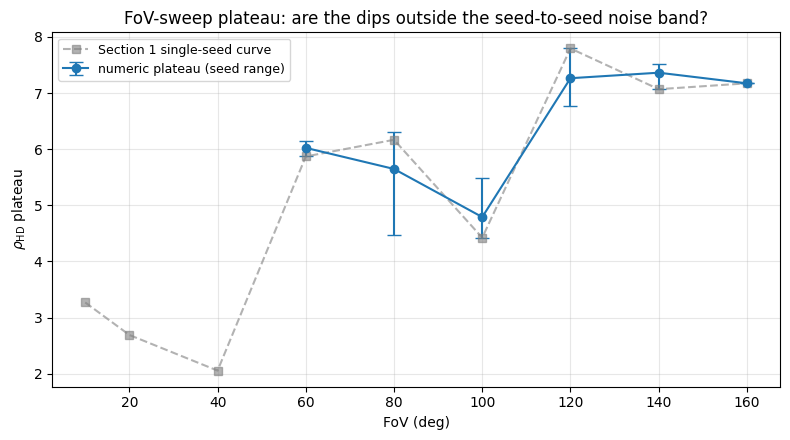

In [47]:

fig, ax = plt.subplots(figsize=(8, 4.5))
yerr_lo = p_mean - p_lo
yerr_hi = p_hi - p_mean
ax.errorbar(fovs_p, p_mean, yerr=[yerr_lo, yerr_hi], fmt="o-", color="C0", capsize=5,
            label="numeric plateau (seed range)")
# overlay the original single-seed Section A curve for comparison
ax.plot(fov_sorted, plateau_clean, "s--", color="gray", alpha=0.6,
        label="Section 1 single-seed curve")
ax.set_xlabel("FoV (deg)"); ax.set_ylabel(r"$\rho_{\rm HD}$ plateau")
ax.set_title("FoV-sweep plateau: are the dips outside the seed-to-seed noise band?")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Conclusion

The FoV=80/FoV=100 ranges overlap substantially (FoV=80: 4.48–6.30; FoV=100: 4.42–5.49),
and so do the FoV=120/FoV=140 ranges (FoV=120: 6.77–7.80; FoV=140: 7.07–7.52). In both
cases, which of the pairs looks "higher" is essentially a coin flip depending on the
specific random star draw — the single-seed dips in Section 1 are **not** a reproducible
property of FoV=100 or FoV=140 specifically.  
